In [16]:
# import packages
import lbsa
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.base import BaseEstimator, TransformerMixin
import re, string, os, emoji
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
import collections
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.metrics import classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from pprint import pprint
from time import time
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.metrics import classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package stopwords to /Users/Mandy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
# read target file
covid = pd.read_csv("Corona_NLP_test.csv").iloc[:2000,:]
covid.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,1,44953,NYC,02-03-2020,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative
1,2,44954,"Seattle, WA",02-03-2020,When I couldn't find hand sanitizer at Fred Me...,Positive
2,3,44955,NaN,02-03-2020,Find out how you can protect yourself and love...,Extremely Positive
3,4,44956,Chicagoland,02-03-2020,#Panic buying hits #NewYork City as anxious sh...,Negative
4,5,44957,"Melbourne, Victoria",03-03-2020,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral


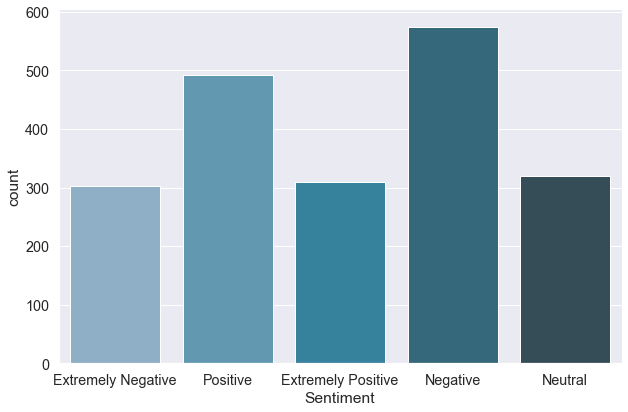

In [11]:
# Target variable distribution
sns.set(style="darkgrid")
sns.set(font_scale=1.3)
target_dist = sns.catplot(x='Sentiment', data=covid, kind="count", height=6, aspect=1.5, palette="PuBuGn_d")
plt.show()

# Extract lexicon-based features

In [12]:
# get lexicons
afinn_lexicon = lbsa.get_lexicon('opinion', language='english', source='afinn')
nrc_lexicon = lbsa.get_lexicon('opinion', language='english', source='nrc')
nrc_sa_lexicon = lbsa.get_lexicon('sa', language='english', source='nrc')
mpqa_lexicon = lbsa.get_lexicon('opinion', language='english', source='mpqa')

In [13]:
# get lexicon-based features
sa_extractor = lbsa.FeatureExtractor(afinn_lexicon, nrc_lexicon, nrc_sa_lexicon, mpqa_lexicon)
feat_dat = pd.DataFrame(sa_extractor.process(covid['OriginalTweet']),columns=sa_extractor.feature_names)

In [14]:
feat_dat

,afinn_positive,afinn_negative,nrc_positive,nrc_negative,nrc_anger,nrc_anticipation,nrc_disgust,nrc_fear,nrc_joy,nrc_sadness,nrc_surprise,nrc_trust,mpqa_positive,mpqa_negative,mpqa_strong_subjectivty
0,0.0,3.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,5.0,5.0,2.0,0.0,3.0,0.0,3.0,1.0,0.0,0.0,3.0,1.0,2.0,2.0
4,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1996,0.0,3.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
1997,0.0,0.0,3.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,3.0,3.0
1998,1.0,3.0,2.0,1.0,0.0,2.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0


Descriptive stats for afinn_positive
------------------------------------
                    count      mean       std  min  25%  50%  75%   max
Sentiment                                                              
Extremely Negative  303.0  0.877888  1.364743  0.0  0.0  0.0  2.0   9.0
Extremely Positive  309.0  4.708738  2.812187  0.0  3.0  4.0  6.0  18.0
Negative            575.0  1.012174  1.413545  0.0  0.0  0.0  2.0   8.0
Neutral             320.0  0.312500  0.934786  0.0  0.0  0.0  0.0   5.0
Positive            493.0  2.133874  1.674270  0.0  1.0  2.0  3.0  10.0


/Users/Mandy/opt/anaconda3/envs/dsfb2env/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


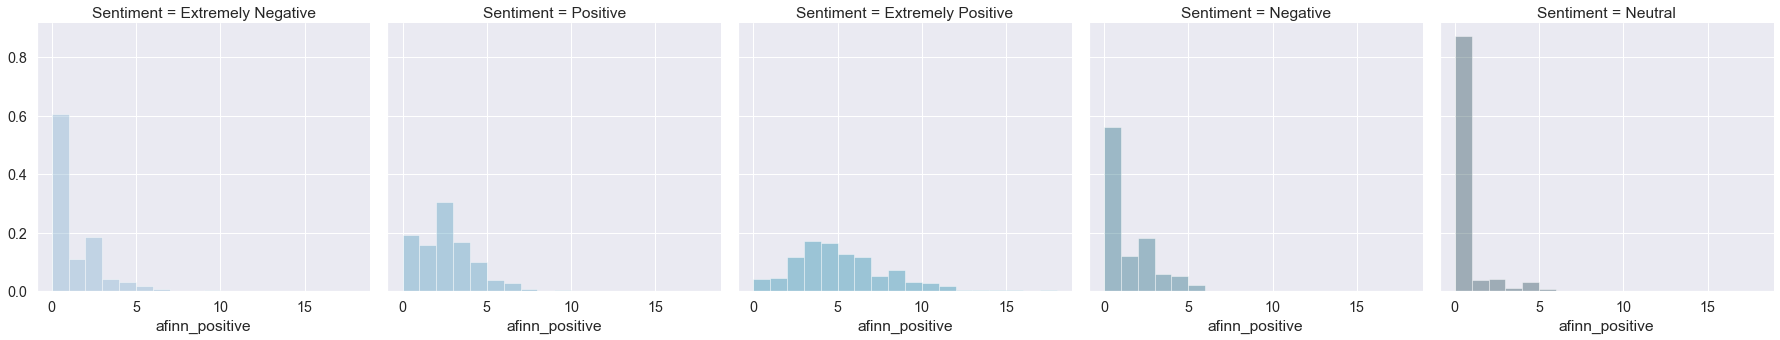

Descriptive stats for afinn_negative
------------------------------------
                    count      mean       std  min  25%  50%  75%   max
Sentiment                                                              
Extremely Negative  303.0  5.927393  3.007938  0.0  4.0  5.0  7.0  17.0
Extremely Positive  309.0  1.288026  1.812086  0.0  0.0  0.0  2.0   8.0
Negative            575.0  2.713043  1.980591  0.0  1.0  2.0  4.0  11.0
Neutral             320.0  0.371875  1.131962  0.0  0.0  0.0  0.0  10.0
Positive            493.0  1.286004  1.794681  0.0  0.0  1.0  2.0  12.0


/Users/Mandy/opt/anaconda3/envs/dsfb2env/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


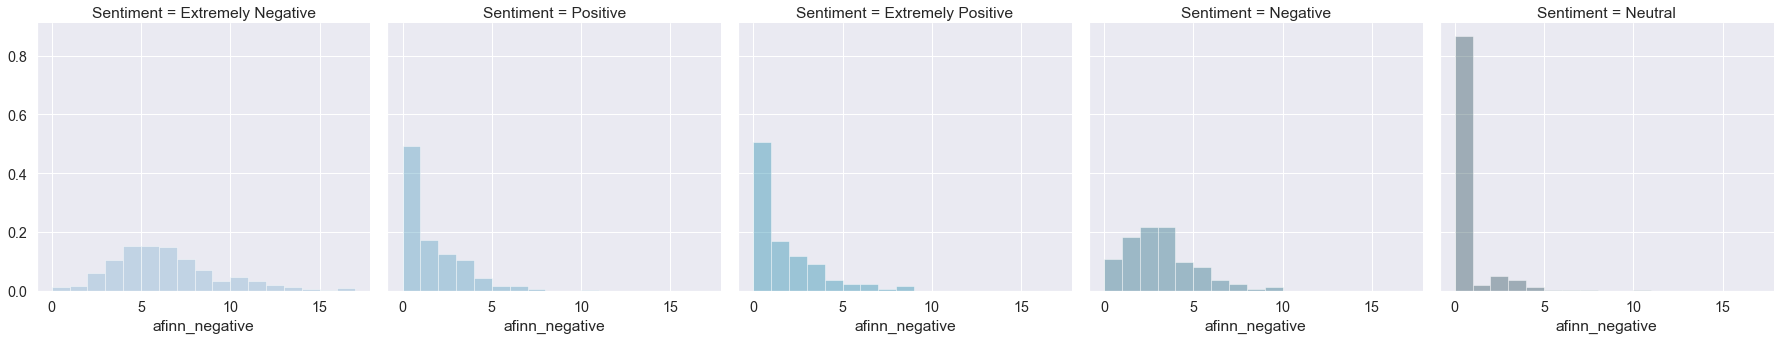

Descriptive stats for nrc_positive
----------------------------------
                    count      mean       std  min  25%  50%  75%  max
Sentiment                                                             
Extremely Negative  303.0  1.772277  1.311295  0.0  1.0  2.0  3.0  6.0
Extremely Positive  309.0  2.724919  1.543333  0.0  2.0  3.0  4.0  8.0
Negative            575.0  1.793043  1.385824  0.0  1.0  2.0  3.0  8.0
Neutral             320.0  1.306250  1.239359  0.0  0.0  1.0  2.0  6.0
Positive            493.0  2.150101  1.534755  0.0  1.0  2.0  3.0  8.0


/Users/Mandy/opt/anaconda3/envs/dsfb2env/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


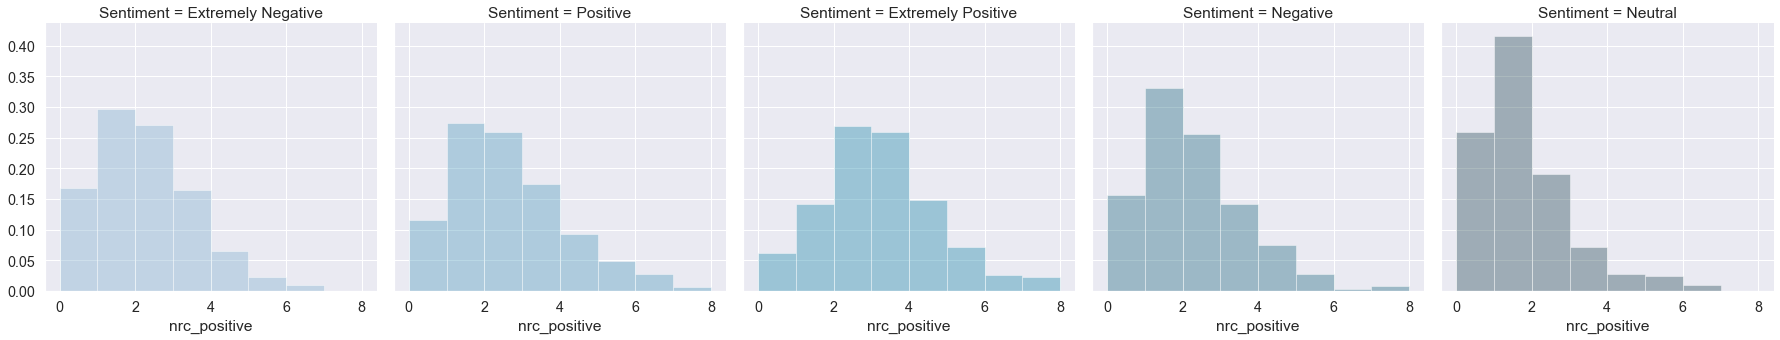

Descriptive stats for nrc_negative
----------------------------------
                    count      mean       std  min  25%  50%  75%  max
Sentiment                                                             
Extremely Negative  303.0  2.521452  1.473396  0.0  1.0  2.0  3.0  8.0
Extremely Positive  309.0  0.990291  1.070518  0.0  0.0  1.0  1.0  4.0
Negative            575.0  1.507826  1.158001  0.0  1.0  1.0  2.0  6.0
Neutral             320.0  0.475000  0.746570  0.0  0.0  0.0  1.0  4.0
Positive            493.0  0.985801  1.126997  0.0  0.0  1.0  2.0  7.0


/Users/Mandy/opt/anaconda3/envs/dsfb2env/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


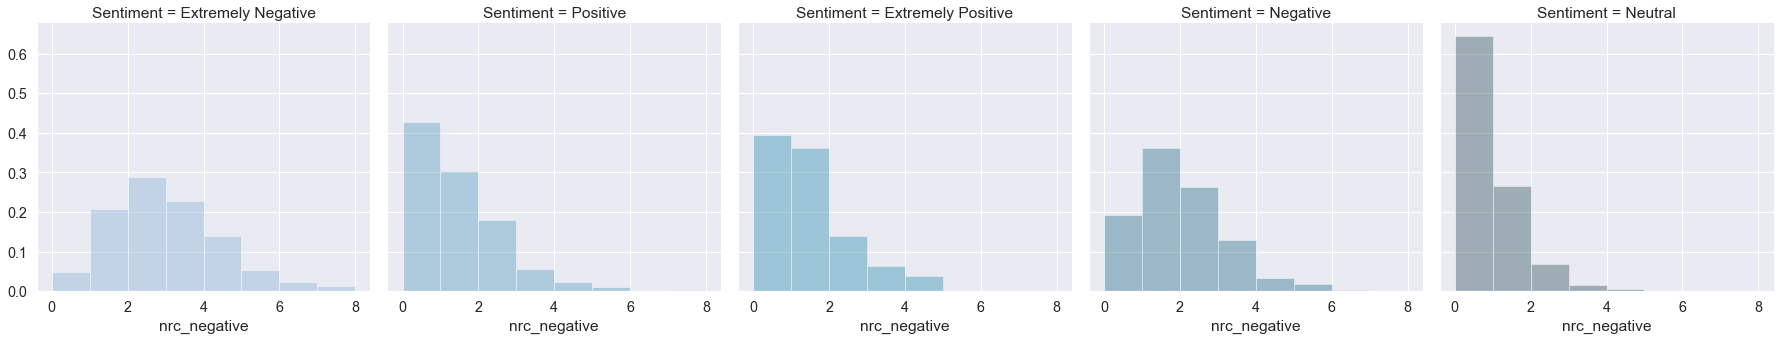

Descriptive stats for nrc_anger
-------------------------------
                    count      mean       std  min  25%  50%  75%  max
Sentiment                                                             
Extremely Negative  303.0  0.775578  0.877872  0.0  0.0  1.0  1.0  4.0
Extremely Positive  309.0  0.336570  0.642127  0.0  0.0  0.0  1.0  4.0
Negative            575.0  0.502609  0.690586  0.0  0.0  0.0  1.0  5.0
Neutral             320.0  0.103125  0.324529  0.0  0.0  0.0  0.0  2.0
Positive            493.0  0.306288  0.571602  0.0  0.0  0.0  1.0  4.0


/Users/Mandy/opt/anaconda3/envs/dsfb2env/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


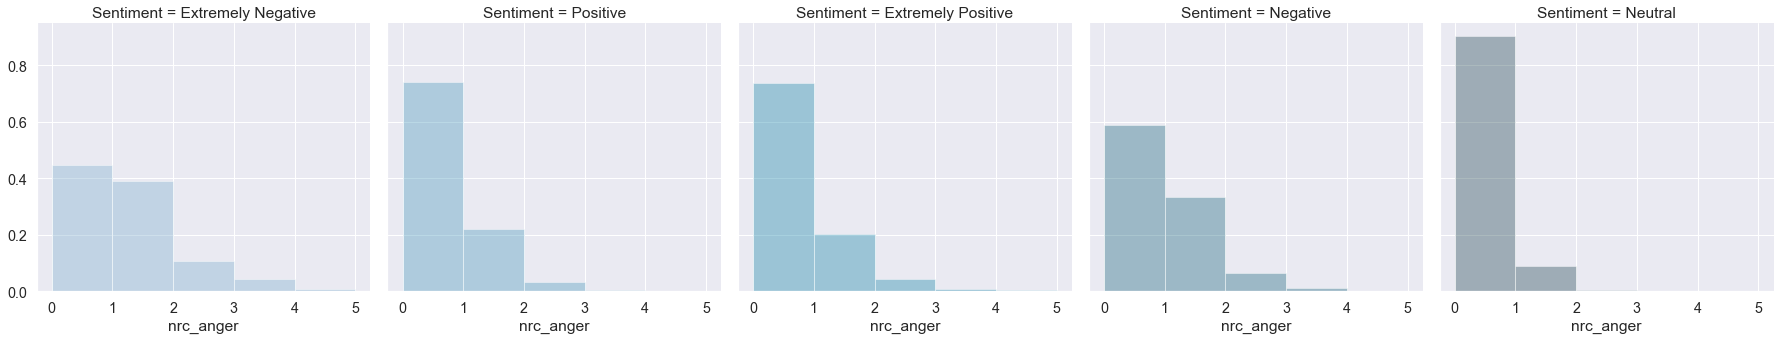

Descriptive stats for nrc_anticipation
--------------------------------------
                    count      mean       std  min  25%  50%  75%  max
Sentiment                                                             
Extremely Negative  303.0  0.844884  0.920174  0.0  0.0  1.0  1.0  4.0
Extremely Positive  309.0  1.365696  1.208300  0.0  0.0  1.0  2.0  7.0
Negative            575.0  0.925217  0.949770  0.0  0.0  1.0  1.0  6.0
Neutral             320.0  0.737500  0.837877  0.0  0.0  1.0  1.0  4.0
Positive            493.0  1.117647  1.083108  0.0  0.0  1.0  2.0  6.0


/Users/Mandy/opt/anaconda3/envs/dsfb2env/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


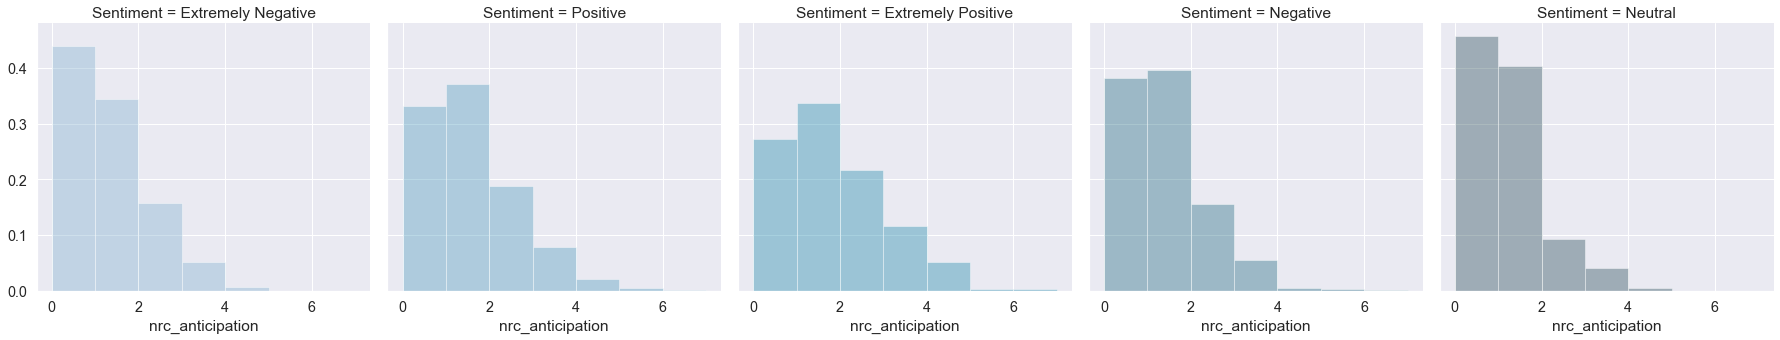

Descriptive stats for nrc_disgust
---------------------------------
                    count      mean       std  min  25%  50%  75%  max
Sentiment                                                             
Extremely Negative  303.0  0.778878  0.910179  0.0  0.0  1.0  1.0  4.0
Extremely Positive  309.0  0.239482  0.529268  0.0  0.0  0.0  0.0  4.0
Negative            575.0  0.384348  0.630330  0.0  0.0  0.0  1.0  4.0
Neutral             320.0  0.140625  0.398555  0.0  0.0  0.0  0.0  3.0
Positive            493.0  0.241379  0.548975  0.0  0.0  0.0  0.0  5.0


/Users/Mandy/opt/anaconda3/envs/dsfb2env/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


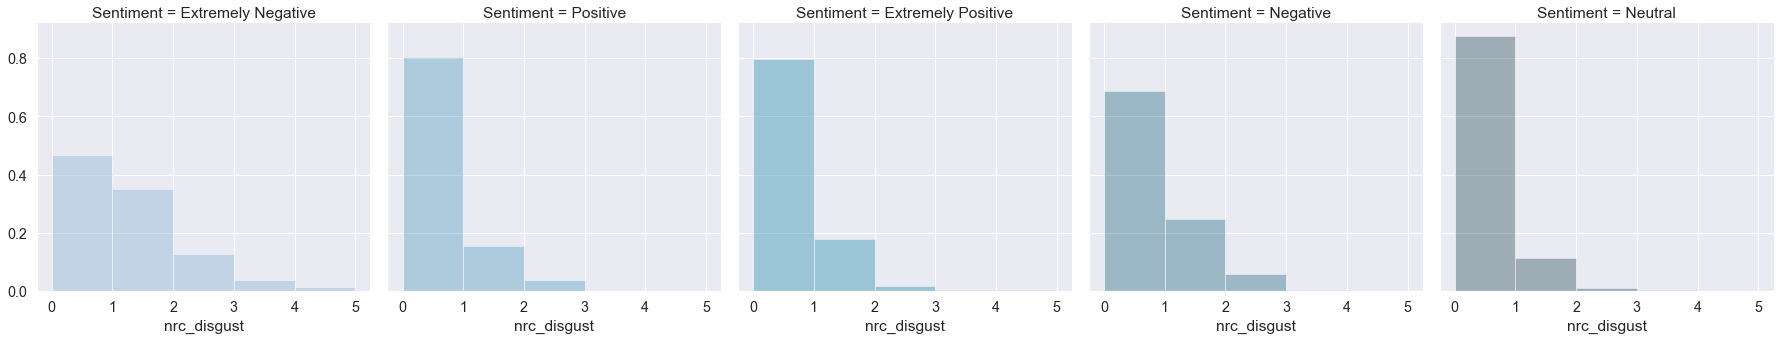

Descriptive stats for nrc_fear
------------------------------
                    count      mean       std  min  25%  50%  75%  max
Sentiment                                                             
Extremely Negative  303.0  1.412541  1.172861  0.0  1.0  1.0  2.0  5.0
Extremely Positive  309.0  0.605178  0.867583  0.0  0.0  0.0  1.0  5.0
Negative            575.0  0.826087  0.886021  0.0  0.0  1.0  1.0  5.0
Neutral             320.0  0.234375  0.505214  0.0  0.0  0.0  0.0  3.0
Positive            493.0  0.574037  0.799578  0.0  0.0  0.0  1.0  4.0


/Users/Mandy/opt/anaconda3/envs/dsfb2env/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


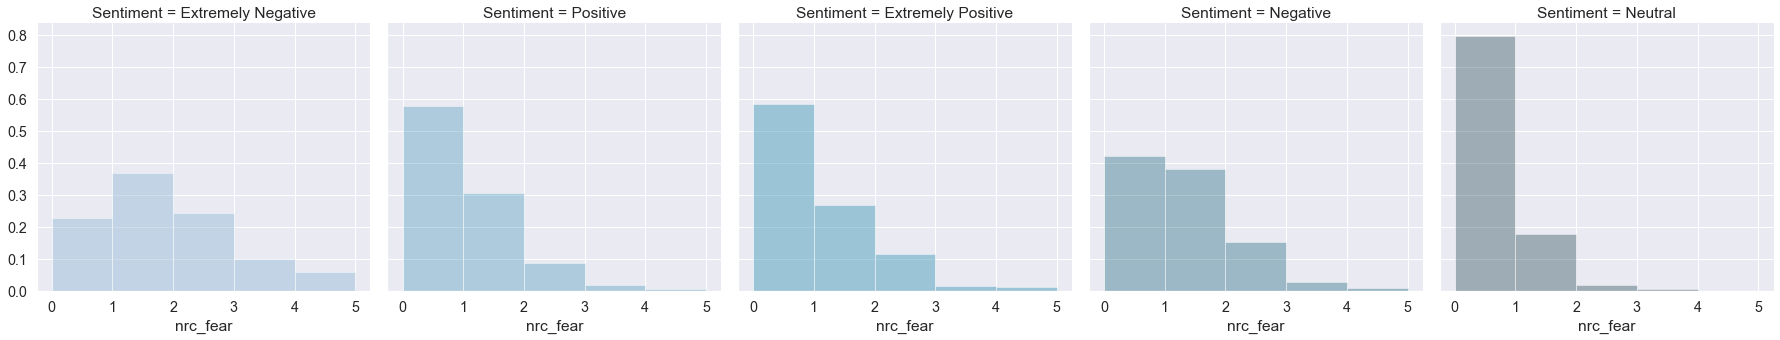

Descriptive stats for nrc_joy
-----------------------------
                    count      mean       std  min  25%  50%  75%  max
Sentiment                                                             
Extremely Negative  303.0  0.640264  0.762943  0.0  0.0  0.0  1.0  4.0
Extremely Positive  309.0  1.317152  1.129474  0.0  0.0  1.0  2.0  7.0
Negative            575.0  0.720000  0.807111  0.0  0.0  1.0  1.0  5.0
Neutral             320.0  0.475000  0.676057  0.0  0.0  0.0  1.0  4.0
Positive            493.0  0.906694  0.977083  0.0  0.0  1.0  1.0  5.0


/Users/Mandy/opt/anaconda3/envs/dsfb2env/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


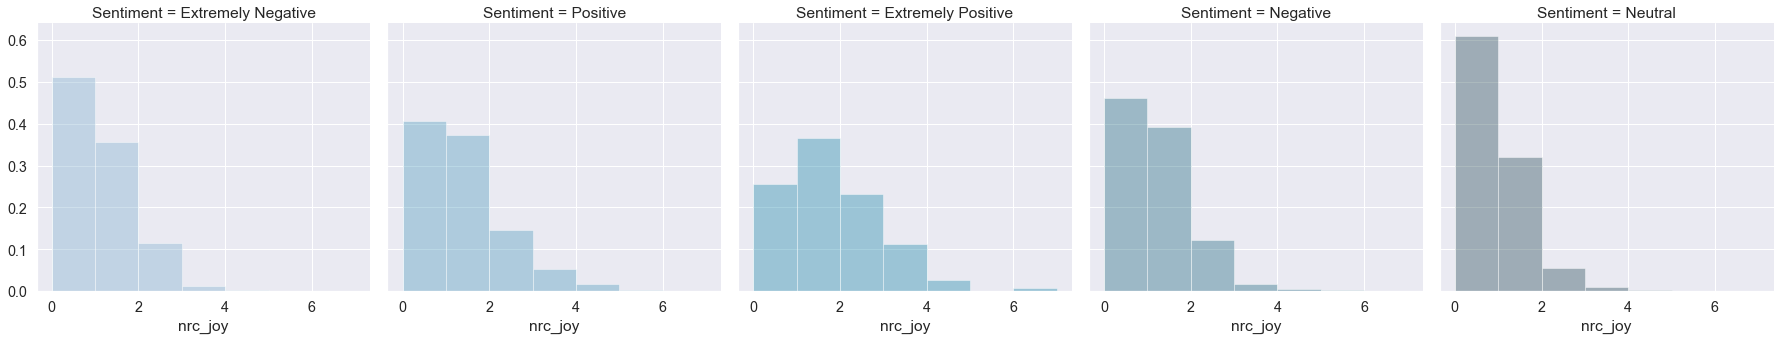

Descriptive stats for nrc_sadness
---------------------------------
                    count      mean       std  min  25%  50%  75%  max
Sentiment                                                             
Extremely Negative  303.0  0.996700  1.114321  0.0  0.0  1.0  2.0  5.0
Extremely Positive  309.0  0.398058  0.674293  0.0  0.0  0.0  1.0  3.0
Negative            575.0  0.606957  0.808462  0.0  0.0  0.0  1.0  5.0
Neutral             320.0  0.140625  0.365743  0.0  0.0  0.0  0.0  2.0
Positive            493.0  0.365112  0.608677  0.0  0.0  0.0  1.0  3.0


/Users/Mandy/opt/anaconda3/envs/dsfb2env/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


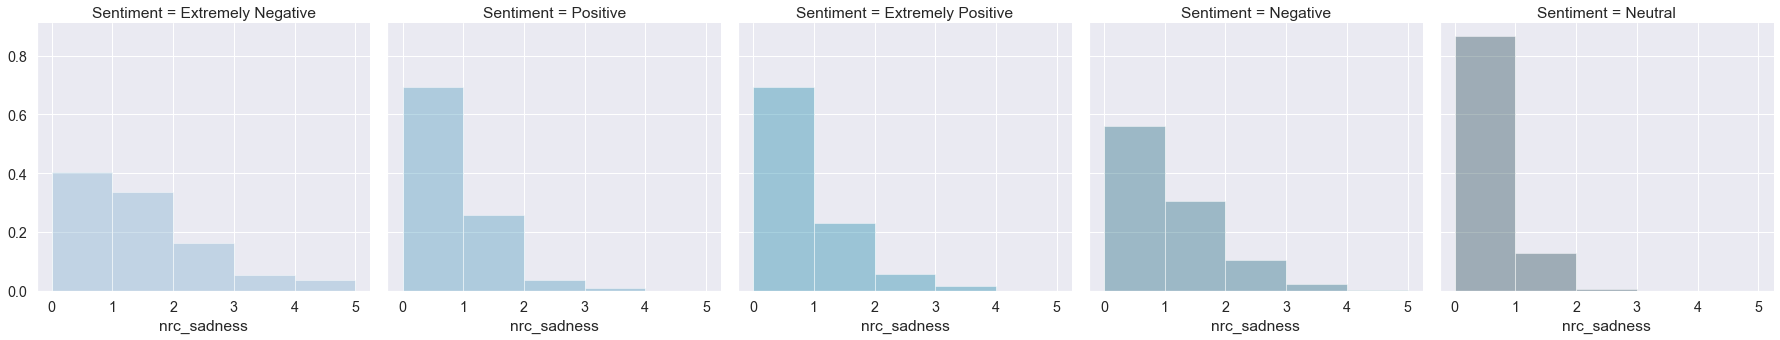

Descriptive stats for nrc_surprise
----------------------------------
                    count      mean       std  min  25%  50%  75%  max
Sentiment                                                             
Extremely Negative  303.0  0.346535  0.582907  0.0  0.0  0.0  1.0  3.0
Extremely Positive  309.0  0.592233  0.850174  0.0  0.0  0.0  1.0  7.0
Negative            575.0  0.389565  0.644918  0.0  0.0  0.0  1.0  4.0
Neutral             320.0  0.215625  0.482034  0.0  0.0  0.0  0.0  3.0
Positive            493.0  0.415822  0.668326  0.0  0.0  0.0  1.0  3.0


/Users/Mandy/opt/anaconda3/envs/dsfb2env/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


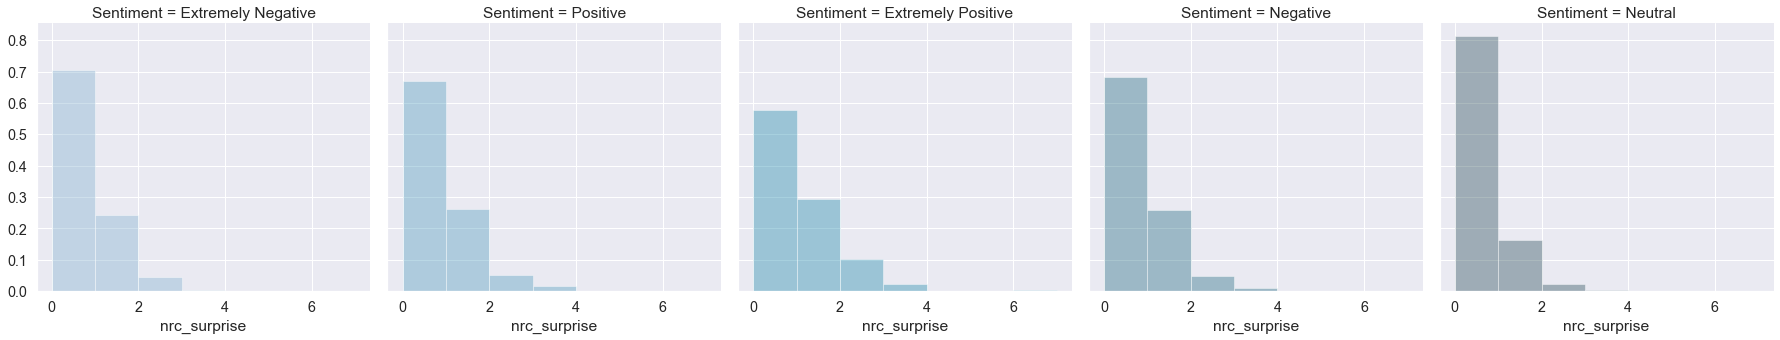

Descriptive stats for nrc_trust
-------------------------------
                    count      mean       std  min  25%  50%  75%  max
Sentiment                                                             
Extremely Negative  303.0  1.029703  1.040142  0.0  0.0  1.0  2.0  5.0
Extremely Positive  309.0  1.608414  1.318719  0.0  1.0  1.0  2.0  7.0
Negative            575.0  1.038261  1.068359  0.0  0.0  1.0  2.0  6.0
Neutral             320.0  0.684375  0.836326  0.0  0.0  0.0  1.0  4.0
Positive            493.0  1.267748  1.181374  0.0  0.0  1.0  2.0  9.0


/Users/Mandy/opt/anaconda3/envs/dsfb2env/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


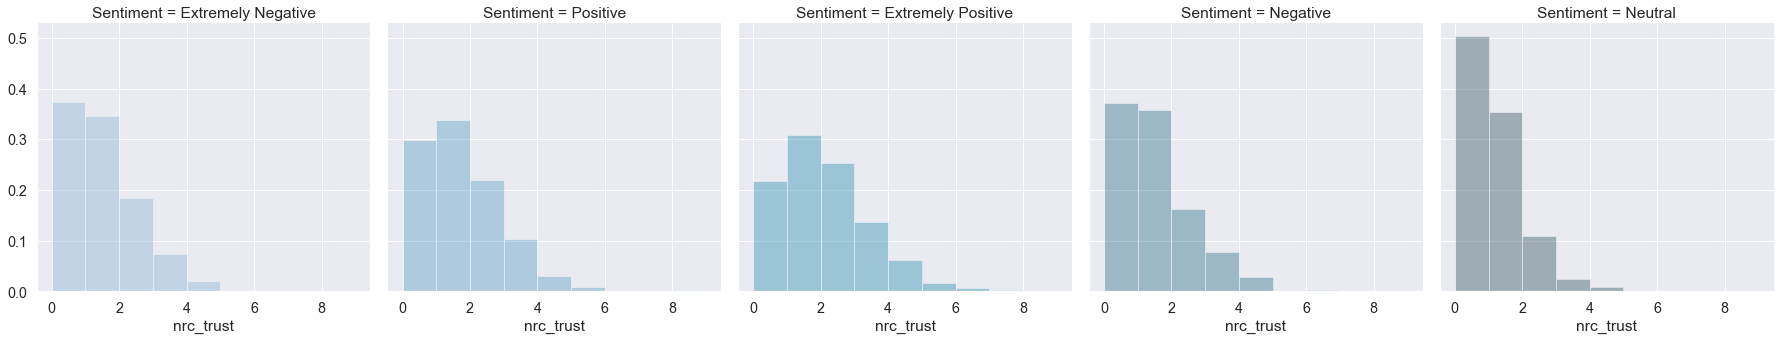

Descriptive stats for mpqa_positive
-----------------------------------
                    count      mean       std  min  25%  50%  75%   max
Sentiment                                                              
Extremely Negative  303.0  1.389439  1.226158  0.0  0.0  1.0  2.0   6.0
Extremely Positive  309.0  3.161812  1.716904  0.0  2.0  3.0  4.0  11.0
Negative            575.0  1.264348  1.283654  0.0  0.0  1.0  2.0   6.0
Neutral             320.0  0.640625  0.965992  0.0  0.0  0.0  1.0   4.0
Positive            493.0  1.825558  1.351751  0.0  1.0  2.0  3.0   8.0


/Users/Mandy/opt/anaconda3/envs/dsfb2env/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


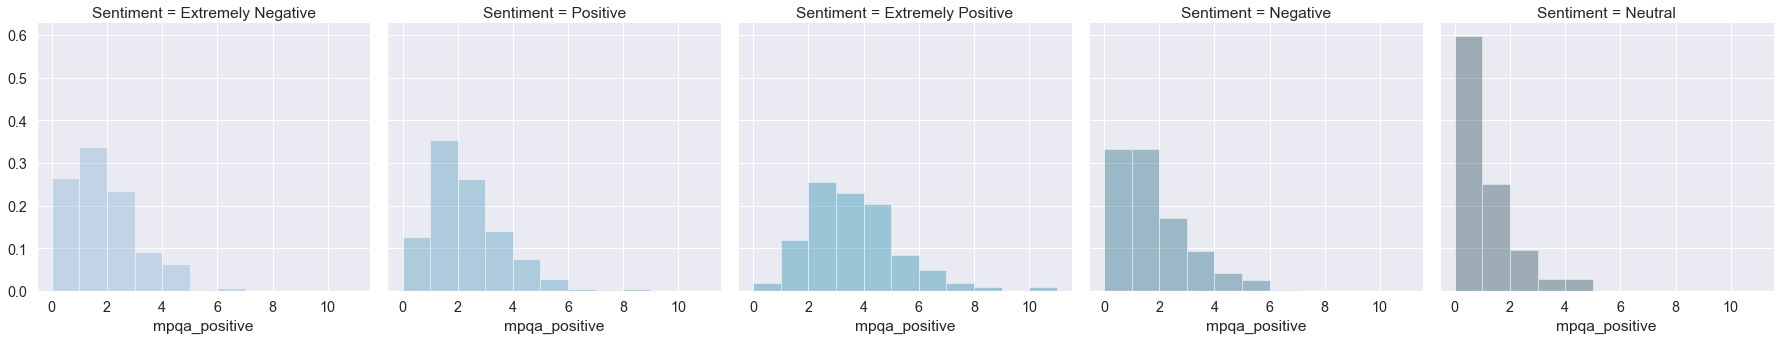

Descriptive stats for mpqa_negative
-----------------------------------
                    count      mean       std  min  25%  50%  75%  max
Sentiment                                                             
Extremely Negative  303.0  2.587459  1.475442  0.0  2.0  2.0  3.0  9.0
Extremely Positive  309.0  0.980583  1.159214  0.0  0.0  1.0  2.0  6.0
Negative            575.0  1.486957  1.107192  0.0  1.0  1.0  2.0  7.0
Neutral             320.0  0.484375  0.841558  0.0  0.0  0.0  1.0  4.0
Positive            493.0  1.012170  1.026010  0.0  0.0  1.0  2.0  5.0


/Users/Mandy/opt/anaconda3/envs/dsfb2env/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


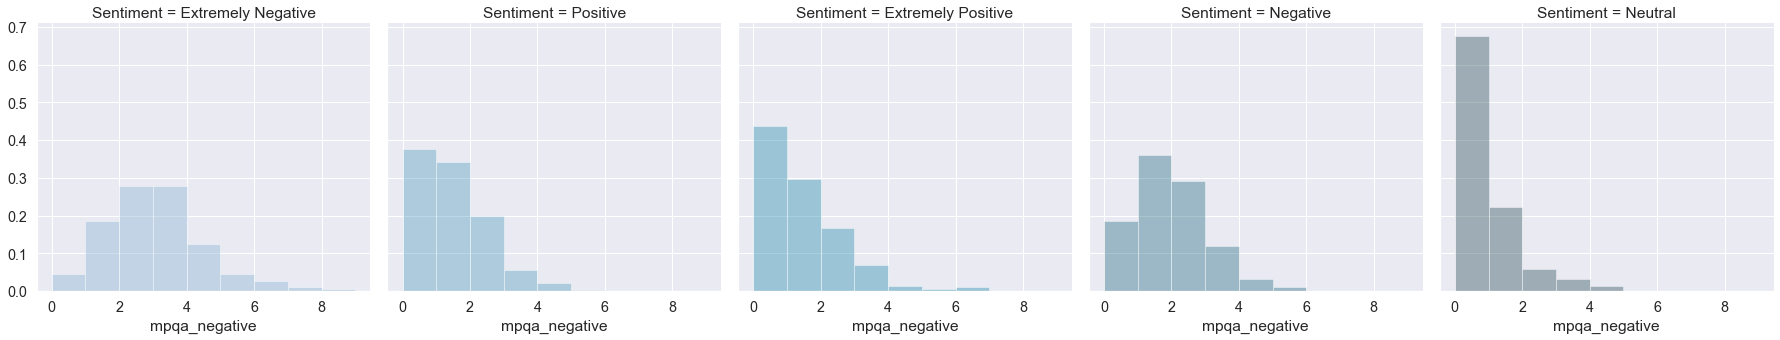

Descriptive stats for mpqa_strong_subjectivty
---------------------------------------------
                    count      mean       std  min  25%  50%  75%   max
Sentiment                                                              
Extremely Negative  303.0  2.518152  1.731716  0.0  1.0  2.0  3.0  11.0
Extremely Positive  309.0  2.300971  1.586274  0.0  1.0  2.0  3.0   8.0
Negative            575.0  1.662609  1.424369  0.0  1.0  1.0  2.0   6.0
Neutral             320.0  0.709375  1.133657  0.0  0.0  0.0  1.0   7.0
Positive            493.0  1.754564  1.505614  0.0  1.0  1.0  3.0   8.0


/Users/Mandy/opt/anaconda3/envs/dsfb2env/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


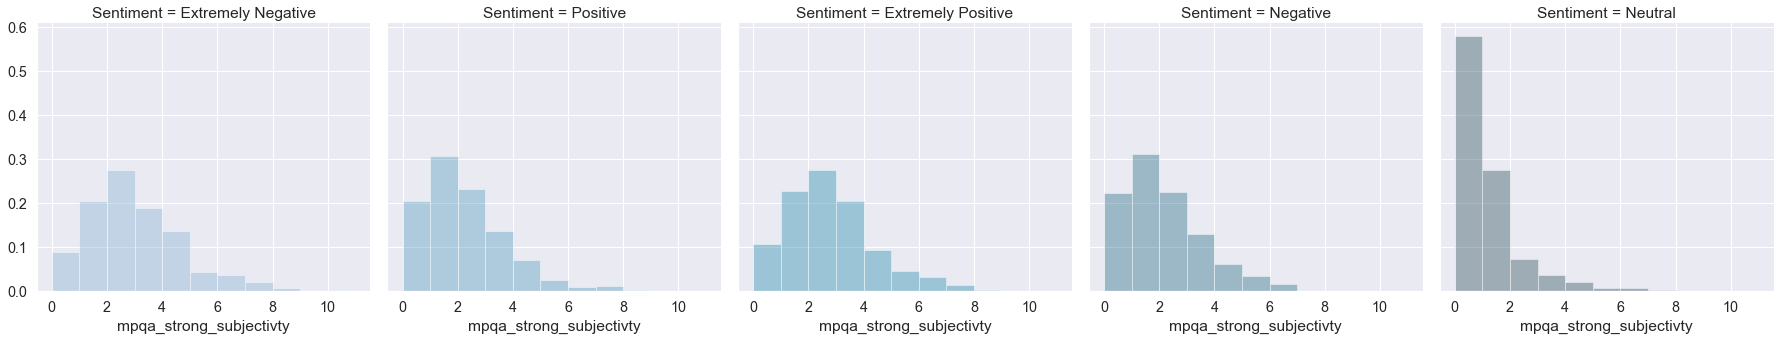

In [15]:
def show_dist(df, col):
    print('Descriptive stats for {}'.format(col))
    print('-'*(len(col)+22))
    print(df.groupby('Sentiment')[col].describe())
    bins = np.arange(df[col].min(), df[col].max() + 1)
    g = sns.FacetGrid(df, col='Sentiment', height=5, hue='Sentiment', palette="PuBuGn_d")
    g = g.map(sns.distplot, col, kde=False, norm_hist=True, bins=bins)
    plt.show()

df_eda = pd.concat([covid,feat_dat],axis=1)

for feature in sa_extractor.feature_names:
    show_dist(df_eda, feature)




# Clean the text

In [9]:
# define functions
class CleanText(BaseEstimator, TransformerMixin):
   
    def remove_mentions(self, input_text):
        return re.sub(r'@\w+', '', input_text)
    
    def remove_urls(self, input_text):
        return re.sub(r'http.?://[^\s]+[\s]?', '', input_text)
    
    def emoji_oneword(self, input_text):
        # By compressing the underscore, the emoji is kept as one word
        return input_text.replace('_','')
    
    def remove_punctuation(self, input_text):
        # Make translation table
        punct = string.punctuation
        trantab = str.maketrans(punct, len(punct)*' ')  # Every punctuation symbol will be replaced by a space
        return input_text.translate(trantab)

    def remove_digits(self, input_text):
        return re.sub(r'\d+', '', input_text)
    
    def to_lower(self, input_text):
        return input_text.lower()
    
    def remove_stopwords(self, input_text):
        stopwords_list = stopwords.words('english')
        # Some words which might indicate a certain sentiment are kept via a whitelist
        whitelist = ["n't", "not", "no"]
        words = input_text.split() 
        clean_words = [word for word in words if (word not in stopwords_list or word in whitelist) and len(word) > 1] 
        return " ".join(clean_words) 
    
    def stemming(self, input_text):
        porter = PorterStemmer()
        words = input_text.split() 
        stemmed_words = [porter.stem(word) for word in words]
        return " ".join(stemmed_words)
    
    def fit(self, X, y=None, **fit_params):
        return self
    
    def transform(self, X, **transform_params):
        clean_X = X.apply(self.remove_mentions).apply(self.remove_urls).apply(self.emoji_oneword).apply(self.remove_punctuation).apply(self.remove_digits).apply(self.to_lower).apply(self.remove_stopwords).apply(self.stemming)
        return clean_X

In [17]:
# clean
ct = CleanText()
sent_clean = ct.fit_transform(covid.OriginalTweet)
print(sent_clean.sample(5))
empty_clean = sent_clean == ''
print('{} records have no words left after text cleaning'.format(sent_clean[empty_clean].count()))
sent_clean.loc[empty_clean] = '[no_text]'

1067    covid kenya psv requir sanit fare bout hike co...
1754    dear halifax let kind groceri store tonight c...
202     warrior leagu sourc say direct play host net t...
618     supermarket unusu busi last night manag said p...
1514    current state local groceri store unreal covid...
Name: OriginalTweet, dtype: object
0 records have no words left after text cleaning


In [18]:
sent_clean

0       trend new yorker encount empti supermarket she...
1       find hand sanit fred meyer turn amazon pack pu...
2                        find protect love one coronaviru
3       panic buy hit newyork citi anxiou shopper stoc...
4       toiletpap dunnypap coronaviru coronavirusaustr...
                              ...                        
1995    groceri store everi frozen veget except okra i...
1996    wegman shoprit retail limit purchas coronaviru...
1997    went groceri store today get normal groceri pe...
1998    went groceri store today panic shop big open n...
1999    allay concern resid rush store panic buy minis...
Name: OriginalTweet, Length: 2000, dtype: object

# Create BOW representation of the data

/Users/Mandy/opt/anaconda3/envs/dsfb2env/lib/python3.8/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


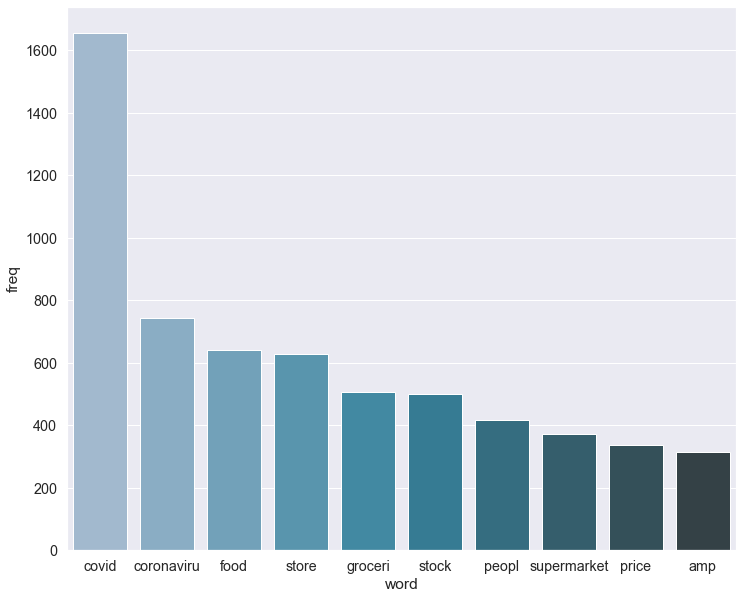

In [32]:
cv = CountVectorizer()
bow = cv.fit_transform(sent_clean)
word_freq = dict(zip(cv.get_feature_names(), np.asarray(bow.sum(axis=0)).ravel()))
word_counter = collections.Counter(word_freq)
word_counter_df = pd.DataFrame(word_counter.most_common(10), columns = ['word', 'freq'])

fig, ax = plt.subplots(figsize=(12, 10))
bar_freq_word = sns.barplot(x="word", y="freq", data=word_counter_df, palette="PuBuGn_d", ax=ax)
plt.show();

In [20]:
cv.get_feature_names_out()

array(['aadya', 'aadyasitara', 'aapl', ..., 'zásobi', 'zásobováni',
       'zástupc'], dtype=object)

In [21]:
bow.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [22]:
pd.DataFrame(bow.toarray(), columns=list(cv.get_feature_names_out()))["covid"]

0       0
1       0
2       0
3       0
4       1
       ..
1995    1
1996    1
1997    1
1998    1
1999    1
Name: covid, Length: 2000, dtype: int64

In [23]:
df_model = df_eda
df_model['clean_text'] = sent_clean
df_model.columns.tolist()

['UserName',
 'ScreenName',
 'Location',
 'TweetAt',
 'OriginalTweet',
 'Sentiment',
 'afinn_positive',
 'afinn_negative',
 'nrc_positive',
 'nrc_negative',
 'nrc_anger',
 'nrc_anticipation',
 'nrc_disgust',
 'nrc_fear',
 'nrc_joy',
 'nrc_sadness',
 'nrc_surprise',
 'nrc_trust',
 'mpqa_positive',
 'mpqa_negative',
 'mpqa_strong_subjectivty',
 'clean_text']

In [24]:
class ColumnExtractor(TransformerMixin, BaseEstimator):
    def __init__(self, cols):
        self.cols = cols

    def transform(self, X, **transform_params):
        return X[self.cols]

    def fit(self, X, y=None, **fit_params):
        return self

In [25]:
# Data split for BOW
X_train, X_test, y_train, y_test = train_test_split(df_model.drop('Sentiment', axis=1), df_model.Sentiment, test_size=0.2, random_state=30)

# Two other types of representation

## TFIDF vectorization

/Users/Mandy/opt/anaconda3/envs/dsfb2env/lib/python3.8/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


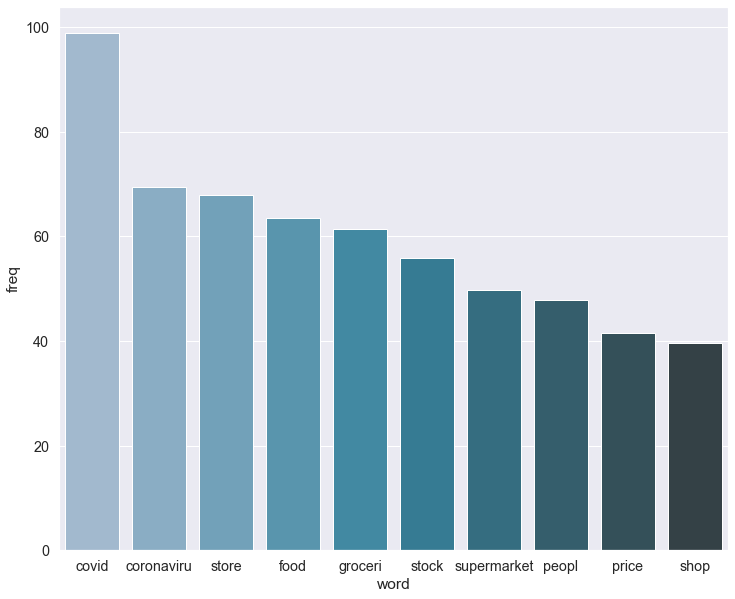

In [33]:
vt = TfidfVectorizer()
TFIDF = vt.fit_transform(sent_clean)
word_freq2 = dict(zip(vt.get_feature_names(), np.asarray(TFIDF.sum(axis=0)).ravel()))
word_counter2 = collections.Counter(word_freq2)
word_counter_df2 = pd.DataFrame(word_counter2.most_common(10), columns = ['word', 'freq'])

fig, ax = plt.subplots(figsize=(12, 10))
bar_freq_word2 = sns.barplot(x="word", y="freq", data=word_counter_df2, palette="PuBuGn_d", ax=ax)
plt.show();

# Train classifiers

## BoW

In [26]:
mnb = MultinomialNB()
logreg = LogisticRegression(max_iter=10000, solver='saga')
countvect = CountVectorizer()

In [27]:
def grid_vect(clf, parameters_clf, X_train, X_test, y_train, y_test, parameters_text=None, vect=None):
    
    textcountscols = ['afinn_positive', 'afinn_negative', 'nrc_positive', 'nrc_negative', 'nrc_anger', 'nrc_anticipation', 'nrc_disgust',
                     'nrc_fear', 'nrc_joy', 'nrc_sadness', 'nrc_surprise', 'nrc_trust', 'mpqa_positive', 'mpqa_negative', 'mpqa_strong_subjectivty']
    
    features = FeatureUnion([('textcounts', ColumnExtractor(cols=textcountscols))
                                 , ('pipe', Pipeline([('cleantext', ColumnExtractor(cols='clean_text')), ('vect', vect)]))]
                                , n_jobs=-1)
  
    pipeline = Pipeline([
        ('features', features)
        , ('clf', clf)
    ])
    
    # Join the parameters dictionaries together
    parameters = dict()
    if parameters_text:
        parameters.update(parameters_text)
    parameters.update(parameters_clf)

    # Make sure you have scikit-learn version 0.19 or higher to use multiple scoring metrics
    grid_search = GridSearchCV(pipeline, parameters, n_jobs=-1, verbose=1, cv=5)
    
    print("Performing grid search...")
    print("pipeline:", [name for name, _ in pipeline.steps])
    print("parameters:")
    pprint(parameters)

    t0 = time()
    grid_search.fit(X_train, y_train)
    print("done in %0.3fs" % (time() - t0))
    print()

    print("Best CV score: %0.3f" % grid_search.best_score_)
    print("Best parameters set:")
    best_parameters = grid_search.best_estimator_.get_params()
    for param_name in sorted(parameters.keys()):
        print("\t%s: %r" % (param_name, best_parameters[param_name]))
        
    print("Test score with best_estimator_: %0.3f" % grid_search.best_estimator_.score(X_test, y_test))
    print("\n")
    print("Classification Report Test Data")
    print(classification_report(y_test, grid_search.best_estimator_.predict(X_test)))
                        
    return grid_search

In [28]:
# Parameter grid settings for the vectorizers (Count and TFIDF)
parameters_vect = {
    'features__pipe__vect__max_df': (0.25, 0.5, 0.75),
    'features__pipe__vect__ngram_range': ((1, 1), (1, 2)),
    'features__pipe__vect__min_df': (1,2)
}

# Parameter grid settings for LogisticRegression
parameters_logreg = {
    'clf__C': (0.25, 0.5, 1.0),
    'clf__penalty': ('l1', 'l2')
}

# Parameter grid settings for MultinomialNB
parameters_mnb = {
    'clf__alpha': (0.25, 0.5, 0.75)
}

In [29]:
# Logistic Regression Estimation
best_logreg_countvect = grid_vect(logreg, parameters_logreg, X_train, X_test, y_train, y_test, parameters_text=parameters_vect, vect=countvect)


Performing grid search...
pipeline: ['features', 'clf']
parameters:
{'clf__C': (0.25, 0.5, 1.0),
 'clf__penalty': ('l1', 'l2'),
 'features__pipe__vect__max_df': (0.25, 0.5, 0.75),
 'features__pipe__vect__min_df': (1, 2),
 'features__pipe__vect__ngram_range': ((1, 1), (1, 2))}
Fitting 5 folds for each of 72 candidates, totalling 360 fits
done in 2030.346s

Best CV score: 0.631
Best parameters set:
	clf__C: 0.25
	clf__penalty: 'l1'
	features__pipe__vect__max_df: 0.25
	features__pipe__vect__min_df: 1
	features__pipe__vect__ngram_range: (1, 1)
Test score with best_estimator_: 0.632


Classification Report Test Data
                    precision    recall  f1-score   support

Extremely Negative       0.66      0.66      0.66        64
Extremely Positive       0.90      0.56      0.69        66
          Negative       0.57      0.65      0.61       110
           Neutral       0.68      0.79      0.73        61
          Positive       0.55      0.56      0.55        99

          accuracy 

In [30]:
logreg_test_preds = X_test.loc[:, ['OriginalTweet']]
logreg_test_preds['Sentiment']=y_test
logreg_test_preds['pred']=best_logreg_countvect.predict(X_test)
logreg_test_preds

,OriginalTweet,Sentiment,pred
1856,The situation of the #Covid_19 #COVID19 wides...,Positive,Positive
364,"#coronavirus scare: In Kashmir, people say by...",Negative,Negative
1948,@RealJamesWoods @DastardlyJabby Im not panick...,Positive,Positive
1458,Scenes from the grocery store at 5 am. \r\r\n\...,Neutral,Neutral
609,To all the plebs out lining the supermarket ne...,Extremely Negative,Extremely Negative
...,...,...,...
1163,This thing is at almost 10$ with taxes its cr...,Positive,Negative
572,I live in the reddest state in the union. Full...,Negative,Negative
1105,Popping in from the abyss to say that working ...,Extremely Negative,Extremely Negative
1903,"If youre in a panic, go for a drive. You are ...",Negative,Negative


In [34]:
mnb2 = MultinomialNB()
countvect2 = CountVectorizer()
# Multinomial NB
best_mnb_countvect = grid_vect(mnb2, parameters_mnb, X_train, X_test, y_train, y_test, parameters_text=parameters_vect, vect=countvect2)

Performing grid search...
pipeline: ['features', 'clf']
parameters:
{'clf__alpha': (0.25, 0.5, 0.75),
 'features__pipe__vect__max_df': (0.25, 0.5, 0.75),
 'features__pipe__vect__min_df': (1, 2),
 'features__pipe__vect__ngram_range': ((1, 1), (1, 2))}
Fitting 5 folds for each of 36 candidates, totalling 180 fits
done in 25.023s

Best CV score: 0.502
Best parameters set:
	clf__alpha: 0.5
	features__pipe__vect__max_df: 0.5
	features__pipe__vect__min_df: 2
	features__pipe__vect__ngram_range: (1, 1)
Test score with best_estimator_: 0.527


Classification Report Test Data
                    precision    recall  f1-score   support

Extremely Negative       0.59      0.66      0.62        64
Extremely Positive       0.65      0.50      0.56        66
          Negative       0.47      0.53      0.50       110
           Neutral       0.76      0.56      0.64        61
          Positive       0.40      0.44      0.42        99

          accuracy                           0.53       400
     

In [35]:
mnb_test_preds = X_test.loc[:, ['OriginalTweet']]
mnb_test_preds['Sentiment']=y_test
mnb_test_preds['pred']=best_mnb_countvect.predict(X_test)
mnb_test_preds

,OriginalTweet,Sentiment,pred
1856,The situation of the #Covid_19 #COVID19 wides...,Positive,Extremely Positive
364,"#coronavirus scare: In Kashmir, people say by...",Negative,Negative
1948,@RealJamesWoods @DastardlyJabby Im not panick...,Positive,Negative
1458,Scenes from the grocery store at 5 am. \r\r\n\...,Neutral,Neutral
609,To all the plebs out lining the supermarket ne...,Extremely Negative,Extremely Negative
...,...,...,...
1163,This thing is at almost 10$ with taxes its cr...,Positive,Negative
572,I live in the reddest state in the union. Full...,Negative,Negative
1105,Popping in from the abyss to say that working ...,Extremely Negative,Extremely Negative
1903,"If youre in a panic, go for a drive. You are ...",Negative,Negative
